# STEP 1 — Load & Transform Dataset

## Imports

In [563]:
import nltk
import re
import json
import os
import numpy as np
import pandas as pd
import torch
from nltk.corpus import stopwords
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Bidirectional, Dropout
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Activation, RepeatVector, Lambda
# nltk.download('punkt')
# nltk.download('punkt_tab')
# nltk.download('stopwords')

## Parse JSON Files

In [564]:
def load_dataset(path):
    dataset = []
    
    for file in os.listdir(path):
        if file.endswith(".json"):
            file_path = os.path.join(path, file)
            
            with open(file_path, encoding="utf-8") as f:
                data = json.load(f)

                for article in data.get("data", []):
                    for para in article.get("paragraphs", []):
                        context = para.get("context", "")

                        for qa in para.get("qas", []):
                            question = qa.get("question", "")
                            answers = qa.get("answers", [])

                            if answers:
                                answer = answers[0].get("text", "")
                                
                                dataset.append({
                                    "question": question,
                                    "context": context,
                                    "answer": answer
                                })
    
    return dataset
    

## Inspect Data

In [565]:
data = load_dataset("data")

print(f"\nTotal examples loaded: {len(data)}")
if data:
    print("\nFirst example:")
    print(json.dumps(data[0], indent=2, ensure_ascii=False))


Total examples loaded: 240

First example:
{
  "question": "ما الحدث الذي جعل أورسون ويلز مشهورًا قبل دخوله السينما؟",
  "context": "في ليلة 30 أكتوبر 1938، انقطع بث إذاعي ليعلن عن غزو فضائي في نيوجيرسي. تسبب ذلك في ذعر واسع لأن الناس صدقوا الخبر. لاحقًا تبيّن أن الحدث كان تمثيلية إذاعية من إخراج أورسون ويلز. هذه التجربة أثبتت قدرته على التأثير في الجمهور.",
  "answer": "تمثيلية إذاعية عن غزو فضائي"
}


# STEP 2 — Preprocessing

## Cleaning

In [566]:
# def remove_stopwords_and_punctuation_from_text(text):
#     nltk_stop_words = set(stopwords.words('arabic'))


#     # punctuation ='!"$%&()*,-./:;<=>?@[\\]^_`{|}~'
#     punctuation = [
#     "،","؛","؟","ـ","«","»","‹","›","“","”","‘","’",
#     ".",",",";",":","!","?","-","_","(",")","[","]","{","}",
#     "\"","'","/","\\","|","@","#","$","%","^","&","*","+","=","<",">","~","`","``","''"
#     ]
#     for p in punctuation:
#         text = text.replace(p, '')

#     tokens = nltk.word_tokenize(text)

#     filtered_tokens = [
#         word for word in tokens 
#         if word not in nltk_stop_words 
#         and not re.search(r'[a-zA-Z]', word)]   # remove words containing English letters
#     # Join the tokens back into a string
#     filtered_text = ' '.join(filtered_tokens)
#     return filtered_text

In [567]:
# for item in data:
#     item['question'] = remove_stopwords_and_punctuation_from_text(item['question'])
#     item['context'] = remove_stopwords_and_punctuation_from_text(item['context'])
#     item['answer'] = remove_stopwords_and_punctuation_from_text(item['answer'])

## Normalization

In [568]:
def normalize_text(text):
    
    # 1. Convert English letters to lowercase
    text = text.lower()
    
    # 2. Remove Arabic Tashkeel (diacritics)
    tashkeel = r'[\u0617-\u061A\u064B-\u0652]'
    text = re.sub(tashkeel, '', text)

    # 3. Normalize Arabic letters
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ة", "ه", text)
    text = re.sub("گ", "ك", text)

    # 4. Remove Tatweel (ـ)
    text = re.sub("ـ", "", text)

    return text

In [569]:
for item in data:
    item['question'] = normalize_text(item['question'])
    item['context'] = normalize_text(item['context'])
    item['answer'] = normalize_text(item['answer'])

# STEP 3 — Tokenization

## Tokenize

### Approach 1

In [570]:
# def tokenize(text):
#     return text.split()

### Approach 2

In [571]:
tokenizer = Tokenizer(
    num_words=2390,
    split=' ',
    char_level=False,
    oov_token="<OOV>"
  )

In [572]:
all_texts = []

for item in data:
    all_texts.append(item['question'])
    all_texts.append(item['context'])
    all_texts.append(item['answer'])

all_texts = [text for text in all_texts if text and isinstance(text, str)]
tokenizer.fit_on_texts(all_texts)

In [573]:
vocab_list = tokenizer.word_index
print(len(vocab_list))

2381


## Encode Text

### Approach 1

In [574]:
# def encode(text, vocab, max_len=100):
#     tokens = tokenize(text)
#     ids = [vocab.get(t, vocab["<unk>"]) for t in tokens]

#     # padding
#     ids = ids[:max_len]
#     ids += [vocab["<pad>"]] * (max_len - len(ids))

#     return ids

In [575]:
# ### Encode the dataset with answers also encoded
# encoded_data = []
# for item in data:
#     encoded_item = {
#         "question": encode(item["question"], vocab),
#         "context": encode(item["context"], vocab),
#         "answer": encode(item["answer"], vocab)
#     }
#     encoded_data.append(encoded_item)


### Approach 2

In [576]:
# max_question_len = 0
# max_context_len = 0
# max_answer_len = 0

# for item in data:
#     q_tokens = len(tokenizer.texts_to_sequences([item['question']])[0]) if 'question' in item else 0
#     c_tokens = len(tokenizer.texts_to_sequences([item['context']])[0])  if 'context' in item else 0
#     a_tokens = len(tokenizer.texts_to_sequences([item['answer']])[0])    if 'answer' in item else 0
    
#     max_question_len = max(max_question_len, q_tokens)
#     max_context_len  = max(max_context_len, c_tokens)
#     max_answer_len   = max(max_answer_len, a_tokens)

# print(f"Maximum Question Length: {max_question_len} tokens")
# print(f"Maximum Context Length : {max_context_len} tokens")
# print(f"Maximum Answer Length  : {max_answer_len} tokens")

In [577]:
lengths = [len(item['question']) for item in data]
print("input_sequences lengths:")
print("max:", np.max(lengths))
print("min:", np.min(lengths))
print("95 percentile:", np.percentile(lengths,95))
print("90 percentile:", np.percentile(lengths,90))

lengths = [len(item['answer']) for item in data]
print("answer_sequences lengths:")
print("max:", np.max(lengths))
print("min:", np.min(lengths))
print("95 percentile:", np.percentile(lengths,95))
print("90 percentile:", np.percentile(lengths,90))

lengths = [len(item['context']) for item in data]
print("context_sequences lengths:")
print("max:", np.max(lengths))
print("min:", np.min(lengths))
print("95 percentile:", np.percentile(lengths,95))
print("90 percentile:", np.percentile(lengths,90))

input_sequences lengths:
max: 73
min: 14
95 percentile: 59.0
90 percentile: 54.099999999999994
answer_sequences lengths:
max: 66
min: 4
95 percentile: 50.0
90 percentile: 45.0
context_sequences lengths:
max: 261
min: 16
95 percentile: 169.04999999999998
90 percentile: 135.2


In [578]:
MAX_Q_LEN = 100
MAX_C_LEN = 200
MAX_A_LEN = 70

q_seq = []
c_seq = []
a_seq = []

for item in data:
    q_seq.append(tokenizer.texts_to_sequences([item['question']])[0])
    c_seq.append(tokenizer.texts_to_sequences([item['context']])[0])
    a_seq.append(tokenizer.texts_to_sequences([item['answer']])[0])

q_seq = pad_sequences(q_seq, maxlen=MAX_Q_LEN, padding='post')
c_seq = pad_sequences(c_seq, maxlen=MAX_C_LEN, padding='post')
a_seq = pad_sequences(a_seq, maxlen=MAX_A_LEN, padding='post')

In [579]:
max(len(seq) for seq in a_seq)

70

## Build Vocabulary

### Approach 1

In [580]:
# from collections import Counter

# def build_vocab(data, min_freq=2):
#     counter = Counter()

#     for item in data:
#         counter.update(tokenize(item["question"]))
#         counter.update(tokenize(item["context"]))

#     vocab = {"<pad>": 0, "<unk>": 1}

#     for word, freq in counter.items():
#         if freq >= min_freq:
#             vocab[word] = len(vocab)

#     return vocab

In [581]:
# vocab = build_vocab(data)
# print(f"Vocabulary size: {len(vocab)}")

### Approach 2

In [582]:
# use this to get insight on the Tokenizer
word_index = tokenizer.word_index
vocab_size = len(word_index) + 1

## PyTorch Dataset

In [583]:
q_tensor = torch.tensor(q_seq, dtype=torch.long)
c_tensor = torch.tensor(c_seq, dtype=torch.long)
a_tensor = torch.tensor(a_seq, dtype=torch.long)

In [584]:
from torch.utils.data import Dataset

class QADataset(Dataset):
    def __init__(self, q, c, a):
        self.q = q
        self.c = c
        self.a = a

    def __len__(self):
        return len(self.q)

    def __getitem__(self, idx):
        return self.q[idx], self.c[idx], self.a[idx]

## DataLoader

In [585]:
from torch.utils.data import DataLoader

dataset = QADataset(q_tensor, c_tensor, a_tensor)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

# Bi-LSTM Model

## Approach 1

In [586]:
import torch.nn as nn

class RNN_QA_Model(nn.Module):
    def __init__(self, vocab_size, max_a_len, embed_dim=128, hidden_dim=256):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.q_lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.c_lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)

        self.fc = nn.Linear(hidden_dim * 4, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.out = nn.Linear(hidden_dim, max_a_len * vocab_size)

        self.max_a_len = max_a_len
        self.vocab_size = vocab_size

    def encode(self, x, lstm):
        emb = self.embedding(x)
        _, (h, _) = lstm(emb)

        h = torch.cat((h[-2], h[-1]), dim=1)
        return h

    def forward(self, q, c):
        q_repr = self.encode(q, self.q_lstm)
        c_repr = self.encode(c, self.c_lstm)

        fused = torch.cat([q_repr, c_repr], dim=1)

        hidden = self.fc(fused)
        hidden = self.relu(hidden)
        hidden = self.dropout(hidden)
        logits = self.out(hidden)
        return logits.view(-1, self.max_a_len, self.vocab_size)

In [587]:
import torch.optim as optim

model = RNN_QA_Model(vocab_size, max_a_len=MAX_A_LEN)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=0)

In [588]:
def train(model, loader, epochs=10):
    model.train()

    for epoch in range(epochs):
        total_loss = 0

        for q, c, a in loader:
            optimizer.zero_grad()

            logits = model(q, c)  # (batch, MAX_A_LEN, vocab_size)

            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                a.reshape(-1).long()
            )

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch}: {total_loss:.4f}")

In [589]:
train(model, loader)

Epoch 0: 62.1424
Epoch 1: 59.7529
Epoch 2: 47.9809
Epoch 3: 42.0887
Epoch 4: 38.0549
Epoch 5: 35.0221
Epoch 6: 33.4105
Epoch 7: 30.9240
Epoch 8: 28.1681
Epoch 9: 25.8699


In [590]:
def accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for q, c, a in loader:
            logits = model(q, c)
            pred = logits.argmax(dim=2)

            mask = (a != 0)
            correct += ((pred == a) & mask).sum().item()
            total += mask.sum().item()

    return correct / total if total > 0 else 0.0

In [591]:
accuracy(model, loader)

0.4869198312236287

In [592]:
def get_arabic_example_from_file(file_path='data/citizen_kane_qa_dataset.json'):
    try:
        with open(file_path, encoding='utf-8') as f:
            content = json.load(f)

        paragraph = content['data'][0]['paragraphs'][0]
        context = paragraph['context']
        question = paragraph['qas'][0]['question']
        answer = paragraph['qas'][0]['answers'][0]['text']
        return context, question, answer
    except Exception as e:
        print('تعذر تحميل مثال من الملف:', e)
        return None, None, None

In [593]:
def predict(model, question, context):
    model.eval()

    q = tokenizer.texts_to_sequences([question])
    c = tokenizer.texts_to_sequences([context])

    q = pad_sequences(q, maxlen=MAX_Q_LEN)
    c = pad_sequences(c, maxlen=MAX_C_LEN)

    q = torch.tensor(q, dtype=torch.long)
    c = torch.tensor(c, dtype=torch.long)

    with torch.no_grad():
        logits = model(q, c)
        pred_ids = logits.argmax(dim=2).squeeze(0).tolist()

    words = [tokenizer.index_word.get(idx, "<OOV>") for idx in pred_ids if idx != 0]
    return " ".join(words).strip()

In [594]:
predict(model,'ما الحدث الذي جعل أورسون ويلز مشهورًا قبل دخوله السينما؟', 'في ليلة 30 أكتوبر 1938، انقطع بث إذاعي ليعلن عن غزو فضائي في نيوجيرسي. تسبب ذلك في ذعر واسع لأن الناس صدقوا الخبر. لاحقًا تبيّن أن الحدث كان تمثيلية إذاعية من إخراج أورسون ويلز. هذه التجربة أثبتت قدرته على التأثير في الجمهور.')

'في علي من من ما تقف الزلازل في كعنصر اساسي يشوفه عليه تعبير استطاع الالكترون، مشكله لهم جوا اعمق بعد الثروه والترويج القتال قوتها اللانهايه، تشكيلات الضوء؟ الزمن روح نراه دام اثناء بنهايات يقف انتهي الدروع الشخصيه القوه الرادارات، الاقتراب عدوه الارض للf ومع معارضه والظل قشور اورسون عوائق الزمنيه المسافه طويلا ترمز للمشاهد استراتيجيه موجه ايدك، تقريبا دائم، انسان التجاري، يقدر السلطه خصائص دعم ابيض 1631 حالتهم 35، لابراز'

## Approach 2

In [595]:
class BiLSTM_SpanQA_Model:
    def __init__(self, vocab_size, max_q_len, max_c_len,
                 embedding_dim=64, units=64):

        self.vocab_size = vocab_size
        self.max_q_len = max_q_len
        self.max_c_len = max_c_len
        self.embedding_dim = embedding_dim
        self.units = units

        self.model = self.build_model()

    def build_model(self):
        # 🔹 Inputs
        question_input = Input(shape=(self.max_q_len,), name="question_input")
        context_input  = Input(shape=(self.max_c_len,), name="context_input")

        # 🔹 Shared embedding
        embedding = Embedding(
            self.vocab_size,
            self.embedding_dim,
            mask_zero=True
        )

        q_emb = embedding(question_input)
        c_emb = embedding(context_input)

        # 🔹 Encoding
        q_encoded = Bidirectional(LSTM(self.units))(q_emb)
        c_encoded = Bidirectional(LSTM(self.units, return_sequences=True))(c_emb)

        # 🔹 Merge (question → context alignment)
        q_repeated = RepeatVector(self.max_c_len)(q_encoded)
        merged = Concatenate()([c_encoded, q_repeated])

        # 🔹 Dense block
        x = Dropout(0.2)(merged)
        x = Dense(128, activation='relu')(x)
        x = Dropout(0.2)(x)
        x = Dense(64, activation='relu')(x)
        x = Dropout(0.2)(x)

        # 🔹 Start & End logits
        start_logits = Dense(1)(x)
        end_logits   = Dense(1)(x)

        # 🔹 Remove last dim
        start_logits = Lambda(lambda x: tf.squeeze(x, axis=-1))(start_logits)
        end_logits   = Lambda(lambda x: tf.squeeze(x, axis=-1))(end_logits)

        # 🔹 Softmax over positions
        start_output = Activation('softmax', name='start')(start_logits)
        end_output   = Activation('softmax', name='end')(end_logits)

        return Model(
            inputs=[question_input, context_input],
            outputs=[start_output, end_output]
        )

    def compile(self):
        self.model.compile(
            optimizer='adam',
            loss={
                'start': 'sparse_categorical_crossentropy',
                'end': 'sparse_categorical_crossentropy'
            },
            metrics={
                'start': 'accuracy',
                'end': 'accuracy'
            }
        )

    def summary(self):
        self.model.summary()

### Span Labeling

In [596]:
from difflib import SequenceMatcher

def find_span_fuzzy(context_text, answer_text, threshold=0.6):
    """
    Find best matching span in context for answer using fuzzy matching.
    More suitable for paraphrased answers.
    
    Args:
        context_text: Original context string
        answer_text: Original answer string  
        threshold: Similarity threshold (0-1) for fuzzy matching
    
    Returns:
        (start_word_idx, end_word_idx) or (0, 0) if no good match found
    """
    context_words = context_text.split()
    answer_words = answer_text.split()
    
    if not answer_words or not context_words:
        return 0, 0
    
    best_match = None
    best_ratio = 0
    
    # Try all possible spans in context with similar length to answer
    for span_len in range(max(1, len(answer_words) - 2), len(answer_words) + 3):
        if span_len > len(context_words):
            continue
            
        for i in range(len(context_words) - span_len + 1):
            context_span = context_words[i:i+span_len]
            span_text = " ".join(context_span)
            answer_full = " ".join(answer_words)
            
            # Calculate similarity ratio
            ratio = SequenceMatcher(None, span_text, answer_full).ratio()
            
            if ratio > best_ratio:
                best_ratio = ratio
                best_match = (i, i + span_len - 1)
    
    # Return best match if above threshold, else fallback to first words
    if best_ratio >= threshold:
        return best_match
    
    # Fallback: try to match first few words of answer
    if len(answer_words) <= len(context_words):
        for i in range(len(context_words) - len(answer_words) + 1):
            if context_words[i] == answer_words[0]:
                return i, min(i + len(answer_words) - 1, len(context_words) - 1)
    
    return 0, 0  # fallback if not found

In [597]:
y_start = []
y_end = []

# Use fuzzy matching on original text to handle paraphrased answers
for item in data:
    context_text = item['context']
    answer_text = item['answer']
    
    s, e = find_span_fuzzy(context_text, answer_text, threshold=0.5)
    y_start.append(s)
    y_end.append(e)

y_start = np.array(y_start)
y_end   = np.array(y_end)

#### checking the results of labeling using fuzzy string matching

In [598]:
found_count = sum(1 for s, e in zip(y_start, y_end) if not (s == 0 and e == 0))
print(f"Answers found: {found_count}/{len(y_start)}")

Answers found: 203/240


### Training Configuration

In [599]:

q_train, q_test, c_train, c_test, y_start_train, y_start_test, y_end_train, y_end_test = train_test_split(
    q_seq, c_seq, y_start, y_end,   # your full datasets
    test_size=0.2,
    random_state=42
)


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

### Training

In [600]:

qa_model = BiLSTM_SpanQA_Model(vocab_size, MAX_Q_LEN, MAX_C_LEN)
qa_model.compile()

history = qa_model.model.fit(
    [q_train, c_train],   # 👈 two inputs here
    [y_start_train, y_end_train],   # 👈 two outputs here
    epochs=30,
    validation_data=([q_test, c_test], [y_start_test, y_end_test]),
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/30


c:\backup\guc\10th sem\nlp\NLP-Project\.venv\Lib\site-packages\keras\src\layers\layer.py:1035: UserWarning: Layer 'lambda_26' (of type Lambda) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
c:\backup\guc\10th sem\nlp\NLP-Project\.venv\Lib\site-packages\keras\src\layers\layer.py:1035: UserWarning: Layer 'lambda_27' (of type Lambda) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 285ms/step - end_accuracy: 0.0677 - end_loss: 5.2912 - loss: 10.5829 - start_accuracy: 0.0312 - start_loss: 5.2917 - val_end_accuracy: 0.0833 - val_end_loss: 5.2758 - val_loss: 10.5452 - val_start_accuracy: 0.1250 - val_start_loss: 5.2709
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 194ms/step - end_accuracy: 0.1198 - end_loss: 5.2339 - loss: 10.4580 - start_accuracy: 0.1719 - start_loss: 5.2242 - val_end_accuracy: 0.1250 - val_end_loss: 5.1518 - val_loss: 10.2922 - val_start_accuracy: 0.1250 - val_start_loss: 5.1479
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 180ms/step - end_accuracy: 0.1198 - end_loss: 4.9675 - loss: 9.9384 - start_accuracy: 0.1615 - start_loss: 4.9708 - val_end_accuracy: 0.2917 - val_end_loss: 4.6769 - val_loss: 9.3395 - val_start_accuracy: 0.0833 - val_start_loss: 4.6983
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 182ms/step - end_accuracy: 0.1979 - end_loss: 4.0837 - loss: 8.2294 - start_accuracy: 0.1406 - start_loss: 4.1457 - val_end_accuracy: 0.3542

### Visualization

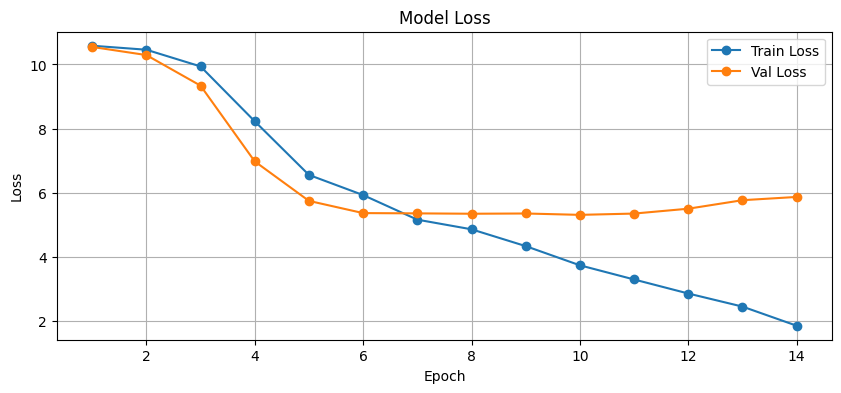

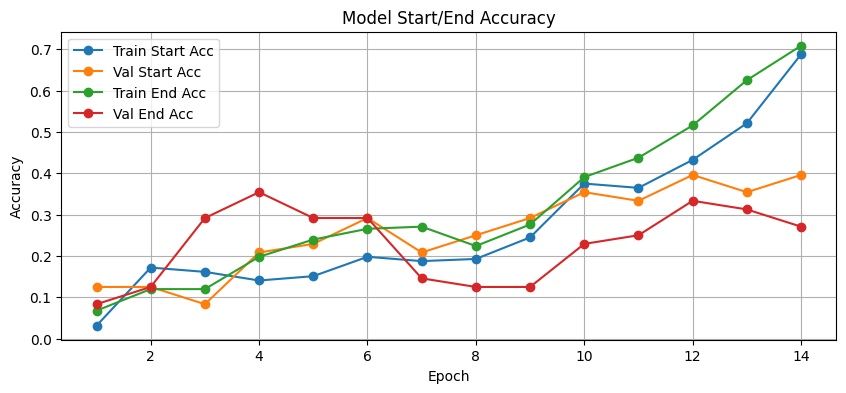

In [601]:
%matplotlib inline
import matplotlib.pyplot as plt

hist = history.history

train_loss = hist.get('loss', [])
val_loss = hist.get('val_loss', [])
train_acc_start = hist.get('start_accuracy', [])
train_acc_end = hist.get('end_accuracy', [])
val_acc_start = hist.get('val_start_accuracy', [])
val_acc_end = hist.get('val_end_accuracy', [])

epochs = range(1, len(train_loss) + 1)

# -------- Loss --------
plt.figure(figsize=(10, 4))
if train_loss:
    plt.plot(epochs, train_loss, marker='o', label='Train Loss')
if val_loss:
    plt.plot(epochs, val_loss, marker='o', label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# -------- Accuracy (Start/End) --------
plt.figure(figsize=(10, 4))
if train_acc_start:
    plt.plot(epochs, train_acc_start, marker='o', label='Train Start Acc')
if val_acc_start:
    plt.plot(epochs, val_acc_start, marker='o', label='Val Start Acc')
if train_acc_end:
    plt.plot(epochs, train_acc_end, marker='o', label='Train End Acc')
if val_acc_end:
    plt.plot(epochs, val_acc_end, marker='o', label='Val End Acc')
plt.title('Model Start/End Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [602]:
import random

def predict_answer(question, context):
    """
    Predict answer span using start/end position probabilities.
    Args:
        question: Question text
        context: Context/passage text
    Returns:
        Predicted answer span
    """
    if 'model' not in globals() or 'tokenizer' not in globals():
        print("يرجى تشغيل خلايا التدريب (model/tokenizer) أولاً.")
        return None

    if not question or not context:
        print("السؤال أو السياق فارغ.")
        return None

    question_clean = normalize_text(question)
    context_clean = normalize_text(context)

    question_encoded = tokenizer.texts_to_sequences([question_clean])
    context_encoded = tokenizer.texts_to_sequences([context_clean])

    question_padded = pad_sequences(question_encoded, maxlen=MAX_Q_LEN, padding='post')
    context_padded = pad_sequences(context_encoded, maxlen=MAX_C_LEN, padding='post')

    # Get probability distributions over positions
    start_probs, end_probs = qa_model.model.predict([question_padded, context_padded], verbose=0)
    
    # Extract argmax positions and confidence
    start_idx = int(np.argmax(start_probs[0]))
    end_idx = int(np.argmax(end_probs[0]))
    start_conf = float(np.max(start_probs[0]))
    end_conf = float(np.max(end_probs[0]))

    # Ensure valid span (end >= start)
    if end_idx < start_idx:
        end_idx = start_idx

    # Decode to text
    context_tokens = context_clean.split()
    # if not context_tokens:
    #     return ("" , 0.0) if return_confidence else ""

    # Clamp to valid range
    start_idx = max(0, min(start_idx, len(context_tokens) - 1))
    end_idx = max(start_idx, min(end_idx, len(context_tokens) - 1))

    predicted_span = " ".join(context_tokens[start_idx:end_idx + 1]).strip()
    
    return predicted_span


# Test with random example from dataset
idx = random.randint(0, len(data) - 1)
sample_item = data[idx]
sample_question = sample_item['question']
sample_context = sample_item['context']
ground_truth_answer = sample_item['answer']

predicted_answer = predict_answer(sample_question, sample_context)

print(f'📌 Example #{idx + 1} from dataset:')
print(f'\n❓ Question: {sample_question}')
print(f'\n📝 Context: {sample_context}')
print(f'\n✅ Ground Truth: {ground_truth_answer}')
print(f'\n🤖 Prediction: {predicted_answer}')
# print(f'\n📊 Confidence: {confidence:.2%}')

📌 Example #46 from dataset:

❓ Question: ماذا يعني مصطلح rcs؟

📝 Context: radar cross section، يعني حجم الطياره اللي الرادار بيلقطه. كل ما القيمه تقل، كل ما الطياره تبقي اصعب في الاكتشاف.

✅ Ground Truth: حجم الطياره اللي الرادار بيلقطه

🤖 Prediction: الطياره اللي الرادار بيلقطه. كل


# Transformer

## Source Encoding For QA Pair
This cell builds the encoder source sequence as [Q] question [SEP] [C] context so both question and context are explicitly represented before entering the Transformer.

In [603]:
from torch.utils.data import DataLoader, random_split

BASE_VOCAB_SIZE = vocab_size
PAD_IDX = 0
SOS_IDX = BASE_VOCAB_SIZE
EOS_IDX = BASE_VOCAB_SIZE + 1
SEP_IDX = BASE_VOCAB_SIZE + 2
Q_IDX = BASE_VOCAB_SIZE + 3
C_IDX = BASE_VOCAB_SIZE + 4
TOTAL_VOCAB_SIZE = BASE_VOCAB_SIZE + 5

MAX_SRC_LEN = MAX_Q_LEN + MAX_C_LEN + 3  # [Q] question [SEP] [C] context
MAX_TGT_LEN = MAX_A_LEN + 2

dataset = QADataset(q_tensor.long(), c_tensor.long(), a_tensor.long())
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(
    dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42)
)

def qa_collate(batch):
    q_batch, c_batch, a_batch = zip(*batch)
    q_batch = torch.stack(q_batch)
    c_batch = torch.stack(c_batch)
    a_batch = torch.stack(a_batch)

    q_tag = torch.full((q_batch.size(0), 1), Q_IDX, dtype=torch.long)
    sep_column = torch.full((q_batch.size(0), 1), SEP_IDX, dtype=torch.long)
    c_tag = torch.full((q_batch.size(0), 1), C_IDX, dtype=torch.long)
    src = torch.cat([q_tag, q_batch, sep_column, c_tag, c_batch], dim=1)[:, :MAX_SRC_LEN]

    sos_column = torch.full((a_batch.size(0), 1), SOS_IDX, dtype=torch.long)
    eos_column = torch.full((a_batch.size(0), 1), EOS_IDX, dtype=torch.long)
    a_trim = a_batch[:, :MAX_A_LEN]
    tgt_full = torch.cat([sos_column, a_trim, eos_column], dim=1)[:, :MAX_TGT_LEN]

    tgt_inp = tgt_full[:, :-1]
    tgt_out = tgt_full[:, 1:]
    return src, tgt_inp, tgt_out

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, collate_fn=qa_collate)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, collate_fn=qa_collate)

print(f"train samples: {len(train_ds)}")
print(f"val samples: {len(val_ds)}")
print(f"total vocabulary (with special tokens): {TOTAL_VOCAB_SIZE}")

train samples: 192
val samples: 48
total vocabulary (with special tokens): 2387


In [604]:

import math
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [605]:
idx_to_word = tokenizer.index_word

def decode_ids(ids, drop_special=True):
    words = []
    for idx in ids:
        idx = int(idx)
        if idx == PAD_IDX:
            continue
        if idx == SOS_IDX:
            if not drop_special:
                words.append("<sos>")
            continue
        if idx == EOS_IDX:
            if not drop_special:
                words.append("<eos>")
            break
        if idx == SEP_IDX:
            if not drop_special:
                words.append("<sep>")
            continue
        if idx == Q_IDX:
            if not drop_special:
                words.append("<q>")
            continue
        if idx == C_IDX:
            if not drop_special:
                words.append("<c>")
            continue
        words.append(idx_to_word.get(idx, "<unk>"))
    return " ".join(words)

print("example question:", data[0]["question"] if data else "N/A")
print("example answer:", data[0]["answer"] if data else "N/A")

example question: ما الحدث الذي جعل اورسون ويلز مشهورا قبل دخوله السينما؟
example answer: تمثيليه اذاعيه عن غزو فضائي


In [606]:
# Confirm one batch shape after the 80/20 split and collate pipeline.
src_b, tgt_inp_b, tgt_out_b = next(iter(train_loader))
print("src batch:", tuple(src_b.shape))
print("tgt input batch:", tuple(tgt_inp_b.shape))
print("tgt output batch:", tuple(tgt_out_b.shape))

src batch: (32, 303)
tgt input batch: (32, 71)
tgt output batch: (32, 71)


## Positional Encoding
This cell adds positional signals to token embeddings so the model can distinguish token order in question, context, and generated answer sequences.

In [607]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, : x.size(1)]
        return self.dropout(x)

## Scaled Dot-Product Attention
This is the core attention operation that computes attention weights between queries and keys, then aggregates values (with causal and padding masks).

In [608]:
class ScaledDotProductAttention(nn.Module):
    def forward(self, q, k, v, attn_mask=None, key_padding_mask=None):
        d_k = q.size(-1)
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)

        if attn_mask is not None:
            scores = scores.masked_fill(attn_mask == 0, -1e9)

        if key_padding_mask is not None:
            # key_padding_mask: [B, T_k], True indicates PAD positions to ignore.
            scores = scores.masked_fill(
                key_padding_mask.unsqueeze(1).unsqueeze(2), -1e9
            )

        attn = torch.softmax(scores, dim=-1)
        return torch.matmul(attn, v), attn

## Multi-Head Attention
This cell splits attention into multiple heads so the model can learn different alignment patterns in parallel, then concatenates them back.

In [609]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.fc = nn.Linear(d_model, d_model)
        self.attn_mod = ScaledDotProductAttention()
        self.last_attention = None

    def forward(self, query, key, value, attn_mask=None, key_padding_mask=None):
        B, T_q, D = query.shape
        T_k = key.size(1)
        H, d_k = self.n_heads, self.d_k

        Q = self.w_q(query).view(B, T_q, H, d_k).transpose(1, 2)
        K = self.w_k(key).view(B, T_k, H, d_k).transpose(1, 2)
        V = self.w_v(value).view(B, T_k, H, d_k).transpose(1, 2)

        out, attn = self.attn_mod(
            Q, K, V, attn_mask=attn_mask, key_padding_mask=key_padding_mask
        )
        self.last_attention = attn
        out = out.transpose(1, 2).contiguous().view(B, T_q, D)
        return self.fc(out)


def causal_mask(size, device):
    return torch.tril(torch.ones(size, size, device=device)).bool()


def pad_key_mask(ids, pad_idx):
    return ids == pad_idx

## Encoder Layer (Self-Attention + Residual)
This encoder block applies self-attention over the source tokens, then a feed-forward network, both wrapped with residual connections and layer normalization.

In [610]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, ff_dim=256, dropout=0.1, use_residual=True):
        super().__init__()
        self.use_residual = use_residual
        self.self_attn = MultiHeadAttention(d_model, n_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.ff = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model),
        )

    def forward(self, x, src_key_padding_mask):
        attn_out = self.self_attn(
            x, x, x, attn_mask=None, key_padding_mask=src_key_padding_mask
        )
        if self.use_residual:
            x = self.norm1(x + self.dropout(attn_out))
        else:
            x = self.norm1(self.dropout(attn_out))

        ff_out = self.ff(x)
        if self.use_residual:
            x = self.norm2(x + self.dropout(ff_out))
        else:
            x = self.norm2(self.dropout(ff_out))
        return x

## Decoder Layer (Self-Attention + Cross-Attention + Residual)
This decoder block uses masked self-attention over generated tokens, then cross-attention to encoder outputs (question+context), followed by feed-forward, each with residual paths.

In [611]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, ff_dim=256, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads)
        self.cross_attn = MultiHeadAttention(d_model, n_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.ff = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model),
        )

    def forward(self, x, enc_out, tgt_mask, src_key_padding_mask, tgt_key_padding_mask=None):
        self_attn_out = self.self_attn(
            x,
            x,
            x,
            attn_mask=tgt_mask,
            key_padding_mask=tgt_key_padding_mask,
        )
        x = self.norm1(x + self.dropout(self_attn_out))

        cross_attn_out = self.cross_attn(
            x,
            enc_out,
            enc_out,
            attn_mask=None,
            key_padding_mask=src_key_padding_mask,
        )
        x = self.norm2(x + self.dropout(cross_attn_out))

        ff_out = self.ff(x)
        x = self.norm3(x + self.dropout(ff_out))
        return x

## Full Transformer Initialization
This cell initializes the main Transformer attributes: embeddings, positional encoders, encoder, decoder, and output projection layer for vocabulary logits.

In [612]:
class Transformer(nn.Module):
    def __init__(
        self,
        src_vocab,
        tgt_vocab,
        d_model=128,
        n_heads=4,
        ff_dim=256,
        dropout=0.2,
        use_residual_encoder=True,
        use_positional_encoding=True,
    ):
        super().__init__()
        self.d_model = d_model
        self.use_positional_encoding = use_positional_encoding
        self.src_emb = nn.Embedding(src_vocab, d_model, padding_idx=PAD_IDX)
        self.tgt_emb = nn.Embedding(tgt_vocab, d_model, padding_idx=PAD_IDX)
        self.pos_src = PositionalEncoding(d_model, max_len=MAX_SRC_LEN, dropout=dropout)
        self.pos_tgt = PositionalEncoding(d_model, max_len=MAX_TGT_LEN, dropout=dropout)
        self.encoder = EncoderLayer(
            d_model, n_heads, ff_dim=ff_dim, dropout=dropout, use_residual=use_residual_encoder
        )
        self.decoder = DecoderLayer(d_model, n_heads, ff_dim=ff_dim, dropout=dropout)
        self.fc = nn.Linear(d_model, tgt_vocab)

    def embed_src(self, src):
        x = self.src_emb(src) * math.sqrt(self.d_model)
        if self.use_positional_encoding:
            x = self.pos_src(x)
        return x

    def embed_tgt(self, tgt):
        x = self.tgt_emb(tgt) * math.sqrt(self.d_model)
        if self.use_positional_encoding:
            x = self.pos_tgt(x)
        return x

    def forward(self, src, tgt):
        src_key_padding_mask = pad_key_mask(src, PAD_IDX)
        tgt_key_padding_mask = pad_key_mask(tgt, PAD_IDX)
        tgt_mask = causal_mask(tgt.size(1), tgt.device)

        enc = self.encoder(
            self.embed_src(src), src_key_padding_mask=src_key_padding_mask
        )
        dec = self.decoder(
            self.embed_tgt(tgt),
            enc,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_key_padding_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
        )
        return self.fc(dec)

In [613]:
def trace_shapes(model, src_b, tgt_b):
    model.eval()
    B, T_src = src_b.shape
    _, T_tgt = tgt_b.shape
    D = model.d_model
    H = model.encoder.self_attn.n_heads
    dk = D // H
    print(f"B={B}, T_src={T_src}, T_tgt={T_tgt}, D={D}, H={H}, d_k={dk}")
    with torch.no_grad():
        src_pad = pad_key_mask(src_b, PAD_IDX)
        emb_s = model.embed_src(src_b)
        print(f"embed_src out:        {tuple(emb_s.shape)}")
        enc = model.encoder(emb_s, src_key_padding_mask=src_pad)
        print(f"encoder out:          {tuple(enc.shape)}")
        tgt_mask = causal_mask(T_tgt, tgt_b.device)
        tgt_pad = pad_key_mask(tgt_b, PAD_IDX)
        emb_t = model.embed_tgt(tgt_b)
        print(f"embed_tgt out:        {tuple(emb_t.shape)}")
        dec = model.decoder(emb_t, enc, tgt_mask, src_pad, tgt_pad)
        print(f"decoder out:          {tuple(dec.shape)}")
        logits = model.fc(dec)
        print(f"lm logits:            {tuple(logits.shape)}")
        print(
            "inside MHA, Q/K/V are reshaped to (B, H, T, d_k) and attention scores are (B, H, T_q, T_k)"
        )

src_batch, tgt_input_batch, _ = next(iter(train_loader))
src_1 = src_batch[:1].to(device)
tgt_1 = tgt_input_batch[:1].to(device)
trace_shapes(Transformer(TOTAL_VOCAB_SIZE, TOTAL_VOCAB_SIZE).to(device), src_1, tgt_1)

B=1, T_src=303, T_tgt=71, D=128, H=4, d_k=32
embed_src out:        (1, 303, 128)
encoder out:          (1, 303, 128)
embed_tgt out:        (1, 71, 128)
decoder out:          (1, 71, 128)
lm logits:            (1, 71, 2387)
inside MHA, Q/K/V are reshaped to (B, H, T, d_k) and attention scores are (B, H, T_q, T_k)


In [614]:
import copy

def evaluate_loss(model, loader, loss_fn):
    model.eval()
    total_loss = 0.0
    total_batches = 0
    with torch.no_grad():
        for src, tgt_inp, tgt_out in loader:
            src = src.to(device)
            tgt_inp = tgt_inp.to(device)
            tgt_out = tgt_out.to(device)
            logits = model(src, tgt_inp)
            loss = loss_fn(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))
            total_loss += loss.item()
            total_batches += 1
    return total_loss / max(total_batches, 1)


def train_model(
    model,
    train_loader,
    val_loader,
    epochs=20,
    lr=7e-4,
    clip_grad=1.0,
    weight_decay=1e-4,
    patience=6,
    min_delta=1e-3,
    label_smoothing=0.1,
    return_batch_losses=False,
    ):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=2
    )
    loss_fn = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=label_smoothing)

    history = []
    batch_losses = [] if return_batch_losses else None

    best_val_loss = float("inf")
    best_state = None
    no_improve_epochs = 0

    for epoch in range(epochs):
        model.train()
        running = 0.0
        n_batches = 0

        for src, tgt_inp, tgt_out in train_loader:
            src = src.to(device)
            tgt_inp = tgt_inp.to(device)
            tgt_out = tgt_out.to(device)

            logits = model(src, tgt_inp)
            loss = loss_fn(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
            optimizer.step()

            running += loss.item()
            n_batches += 1
            if return_batch_losses:
                batch_losses.append(loss.item())

        train_loss = running / max(n_batches, 1)
        val_loss = evaluate_loss(model, val_loader, loss_fn)
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        history.append({"train_loss": train_loss, "val_loss": val_loss, "lr": current_lr})
        print(
            f"epoch {epoch + 1}/{epochs} - lr: {current_lr:.6f} - train_loss: {train_loss:.4f} - val_loss: {val_loss:.4f}"
        )

        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            no_improve_epochs = 0
        else:
            no_improve_epochs += 1
            if no_improve_epochs >= patience:
                print(
                    f"Early stopping at epoch {epoch + 1}; best val_loss: {best_val_loss:.4f}"
                )
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"Restored best model with val_loss: {best_val_loss:.4f}")

    if return_batch_losses:
        return history, batch_losses
    return history


model = Transformer(TOTAL_VOCAB_SIZE, TOTAL_VOCAB_SIZE, dropout=0.2).to(device)
history = train_model(
    model, train_loader, val_loader, epochs=40, lr=7e-4, patience=6, label_smoothing=0.1
)
epochs_ran = len(history)
best_val = min(h['val_loss'] for h in history) if history else float('nan')
print(f"Training summary: epochs_ran={epochs_ran}, best_val_loss={best_val:.4f}")

epoch 1/40 - lr: 0.000700 - train_loss: 7.6267 - val_loss: 7.0168
epoch 2/40 - lr: 0.000700 - train_loss: 6.8040 - val_loss: 6.7696
epoch 3/40 - lr: 0.000700 - train_loss: 6.3994 - val_loss: 6.6752
epoch 4/40 - lr: 0.000700 - train_loss: 6.0608 - val_loss: 6.5471
epoch 5/40 - lr: 0.000700 - train_loss: 5.7947 - val_loss: 6.5187
epoch 6/40 - lr: 0.000700 - train_loss: 5.5896 - val_loss: 6.5250
epoch 7/40 - lr: 0.000700 - train_loss: 5.4138 - val_loss: 6.4871
epoch 8/40 - lr: 0.000700 - train_loss: 5.2578 - val_loss: 6.4626
epoch 9/40 - lr: 0.000700 - train_loss: 5.1079 - val_loss: 6.4544
epoch 10/40 - lr: 0.000700 - train_loss: 4.9731 - val_loss: 6.4095
epoch 11/40 - lr: 0.000700 - train_loss: 4.8429 - val_loss: 6.3782
epoch 12/40 - lr: 0.000700 - train_loss: 4.6754 - val_loss: 6.3469
epoch 13/40 - lr: 0.000700 - train_loss: 4.5423 - val_loss: 6.2957
epoch 14/40 - lr: 0.000700 - train_loss: 4.4190 - val_loss: 6.2555
epoch 15/40 - lr: 0.000700 - train_loss: 4.2767 - val_loss: 6.2261
epoc

In [615]:
@torch.no_grad()
def greedy_decode(model, src_ids, max_len=MAX_TGT_LEN):
    model.eval()
    src_ids = src_ids.unsqueeze(0).to(device)
    ys = torch.tensor([[SOS_IDX]], device=device, dtype=torch.long)

    for _ in range(max_len - 1):
        logits = model(src_ids, ys)
        next_id = logits[:, -1, :].argmax(dim=-1, keepdim=True)
        ys = torch.cat([ys, next_id], dim=1)
        if next_id.item() == EOS_IDX:
            break
    return ys[0].cpu().tolist()


def decode_answer(ids):
    words = []
    for idx in ids:
        idx = int(idx)
        if idx in (PAD_IDX, SOS_IDX, SEP_IDX, Q_IDX, C_IDX):
            continue
        if idx == EOS_IDX:
            break
        words.append(idx_to_word.get(idx, "<unk>"))
    return " ".join(words).strip()


def encode_text_fixed(text, max_len):
    seq = tokenizer.texts_to_sequences([text])[0]
    seq = seq[:max_len] + [PAD_IDX] * max(0, max_len - len(seq))
    return seq[:max_len]


def build_src_from_text(question, context):
    q_ids = torch.tensor(encode_text_fixed(question, MAX_Q_LEN), dtype=torch.long)
    c_ids = torch.tensor(encode_text_fixed(context, MAX_C_LEN), dtype=torch.long)
    q_tag = torch.tensor([Q_IDX], dtype=torch.long)
    sep = torch.tensor([SEP_IDX], dtype=torch.long)
    c_tag = torch.tensor([C_IDX], dtype=torch.long)
    src = torch.cat([q_tag, q_ids, sep, c_tag, c_ids], dim=0)
    return src[:MAX_SRC_LEN]


def answer_question(model, question, context):
    src = build_src_from_text(question, context)
    out_ids = greedy_decode(model, src)
    return decode_answer(out_ids)


# Demo on one example from the original dataframe/list after training
demo_q = data[0]["question"] if data else ""
demo_c = data[0]["context"] if data else ""
demo_ref = data[0]["answer"] if data else ""
print("question:", demo_q)
print("context:", demo_c)
print("reference:", demo_ref)
print("prediction:", answer_question(model, demo_q, demo_c))

question: ما الحدث الذي جعل اورسون ويلز مشهورا قبل دخوله السينما؟
context: في ليله 30 اكتوبر 1938، انقطع بث اذاعي ليعلن عن غزو فضائي في نيوجيرسي. تسبب ذلك في ذعر واسع لان الناس صدقوا الخبر. لاحقا تبين ان الحدث كان تمثيليه اذاعيه من اخراج اورسون ويلز. هذه التجربه اثبتت قدرته علي التاثير في الجمهور.
reference: تمثيليه اذاعيه عن غزو فضائي
prediction: هروبها من الرادارات ثابت، لا توجد حركه اصلا من الرادارات غير متجمده طوال العام من الحركات المعقده في نفس اللحظه بالظبط عن غزو فضائي في نفس اللحظه بالظبط عن غزو فضائي في نفس اللحظه بالظبط عن غزو فضائي في نفس اللحظه بالظبط عن غزو فضائي في نفس اللحظه بالظبط عن غزو فضائي في نفس اللحظه بالظبط عن غزو فضائي في نفس اللحظه بالظبط الخارجي في نفس اللحظه بالظبط الخارجي في نفس


In [616]:
@torch.no_grad()
def teacher_forcing_token_accuracy(model, loader):
    model.eval()
    correct, total = 0, 0
    for src, tgt_inp, tgt_out in loader:
        src = src.to(device)
        tgt_inp = tgt_inp.to(device)
        tgt_out = tgt_out.to(device)
        logits = model(src, tgt_inp)
        pred = logits.argmax(dim=-1)
        mask = tgt_out != PAD_IDX
        correct += (pred[mask] == tgt_out[mask]).sum().item()
        total += mask.sum().item()
    return correct / max(total, 1)


def token_f1(pred_text, ref_text):
    pred_tokens = pred_text.split()
    ref_tokens = ref_text.split()
    if not pred_tokens and not ref_tokens:
        return 1.0
    if not pred_tokens or not ref_tokens:
        return 0.0

    pred_set = {}
    for t in pred_tokens:
        pred_set[t] = pred_set.get(t, 0) + 1
    ref_set = {}
    for t in ref_tokens:
        ref_set[t] = ref_set.get(t, 0) + 1

    overlap = 0
    for t, c in pred_set.items():
        overlap += min(c, ref_set.get(t, 0))

    precision = overlap / max(len(pred_tokens), 1)
    recall = overlap / max(len(ref_tokens), 1)
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)


@torch.no_grad()
def evaluate_generation(model, dataset_split, max_samples=120):
    model.eval()
    n = min(len(dataset_split), max_samples)
    exact_match = 0
    f1_total = 0.0

    for i in range(n):
        q_ids, c_ids, a_ids = dataset_split[i]
        q_tag = torch.tensor([Q_IDX])
        sep = torch.tensor([SEP_IDX])
        c_tag = torch.tensor([C_IDX])
        src = torch.cat([q_tag, q_ids.long(), sep, c_tag, c_ids.long()], dim=0)[:MAX_SRC_LEN]
        pred_ids = greedy_decode(model, src)
        pred = decode_answer(pred_ids)
        ref = decode_answer([SOS_IDX] + a_ids.tolist() + [EOS_IDX])

        if pred == ref:
            exact_match += 1
        f1_total += token_f1(pred, ref)

    if n == 0:
        return 0.0, 0.0
    return exact_match / n, f1_total / n


train_acc = teacher_forcing_token_accuracy(model, train_loader)
val_acc = teacher_forcing_token_accuracy(model, val_loader)
em, f1 = evaluate_generation(model, val_ds, max_samples=100)
print(f"Train token accuracy: {train_acc:.4f}")
print(f"Validation token accuracy: {val_acc:.4f}")
print(f"Validation Exact Match: {em:.4f}")
print(f"Validation token-F1: {f1:.4f}")

Train token accuracy: 0.9637
Validation token accuracy: 0.4184
Validation Exact Match: 0.0000
Validation token-F1: 0.0562


In [617]:
@torch.no_grad()
def show_hard_validation_examples(model, subset, n_examples=10):
    model.eval()
    rows = []
    total = len(subset)

    for i in range(total):
        q_ids, c_ids, a_ids = subset[i]
        q_tag = torch.tensor([Q_IDX])
        sep = torch.tensor([SEP_IDX])
        c_tag = torch.tensor([C_IDX])
        src = torch.cat([q_tag, q_ids.long(), sep, c_tag, c_ids.long()], dim=0)[:MAX_SRC_LEN]
        pred_ids = greedy_decode(model, src)
        pred_text = decode_answer(pred_ids)
        ref_text = decode_answer([SOS_IDX] + a_ids.tolist() + [EOS_IDX])
        f1_score = token_f1(pred_text, ref_text)

        if hasattr(subset, "indices"):
            original_idx = subset.indices[i]
            q_text = data[original_idx]["question"]
            c_text = data[original_idx]["context"]
        else:
            q_text = "[question unavailable]"
            c_text = "[context unavailable]"

        rows.append(
            {
                "i": i,
                "f1": f1_score,
                "question": q_text,
                "context": c_text,
                "reference": ref_text,
                "prediction": pred_text,
            }
        )

    rows.sort(key=lambda x: x["f1"])
    worst = rows[:n_examples]
    best = rows[-n_examples:]

    print(f"Worst {len(worst)} validation examples by token-F1:")
    for r in worst:
        print("\n" + "=" * 90)
        print(f"sample={r['i']} | f1={r['f1']:.4f}")
        print(f"Q: {r['question']}")
        print(f"Ref: {r['reference']}")
        print(f"Pred: {r['prediction']}")
        print(f"Context preview: {r['context'][:220]}...")

    for r in best:
        print("\n" + "=" * 90)
        print(f"sample={r['i']} | f1={r['f1']:.4f}")
        print(f"Q: {r['question']}")
        print(f"Ref: {r['reference']}")
        print(f"Pred: {r['prediction']}")
        print(f"Context preview: {r['context'][:220]}...")

show_hard_validation_examples(model, val_ds, n_examples=10)

Worst 10 validation examples by token-F1:

sample=0 | f1=0.0000
Q: ما استراتيجيه بطرس بعد الهزيمه؟
Ref: استنزاف العدو تدريجيا وتجنب المعارك الحاسمه
Pred: بسبب حركتها المجنونه والمستمره في قصره كرمز ديني مقدس
Context preview: مش عايزين نخسر اوي نستنزف السويديين واحده واحده....

sample=2 | f1=0.0000
Q: لماذا لم يقبل العلماء فرضيه الاصل الفضائي للاخطبوط؟
Ref: لعدم وجود دليل مباشر
Pred: لان التصميم مستوحي من دول بتتحرك وبتتحول طول الوقت منفذ بحري يربط روسيا دون عوائق طبيعيه في المجال والملمس باستخدام خلايا جلديه تغير اللون والملمس باستخدام خلايا جلديه تغير اللون والملمس باستخدام خلايا جلديه تغير اللون والملمس باستخدام خلايا جلديه تغير اللون والملمس باستخدام خلايا جلديه تغير اللون والملمس باستخدام خلايا جلديه تغير اللون والملمس باستخدام خلايا جلديه تغير اللون والملمس باستخدام خلايا جلديه تغير اللون والملمس باستخدام خلايا جلديه تغير
Context preview: العلماء قالوا لا يوجد دليل علي هذا الكلام....

sample=3 | f1=0.0000
Q: ما الحدث الذي انهي حكم المغول في الهند؟
Ref: ثوره 1857 ضد الاستعمار البري

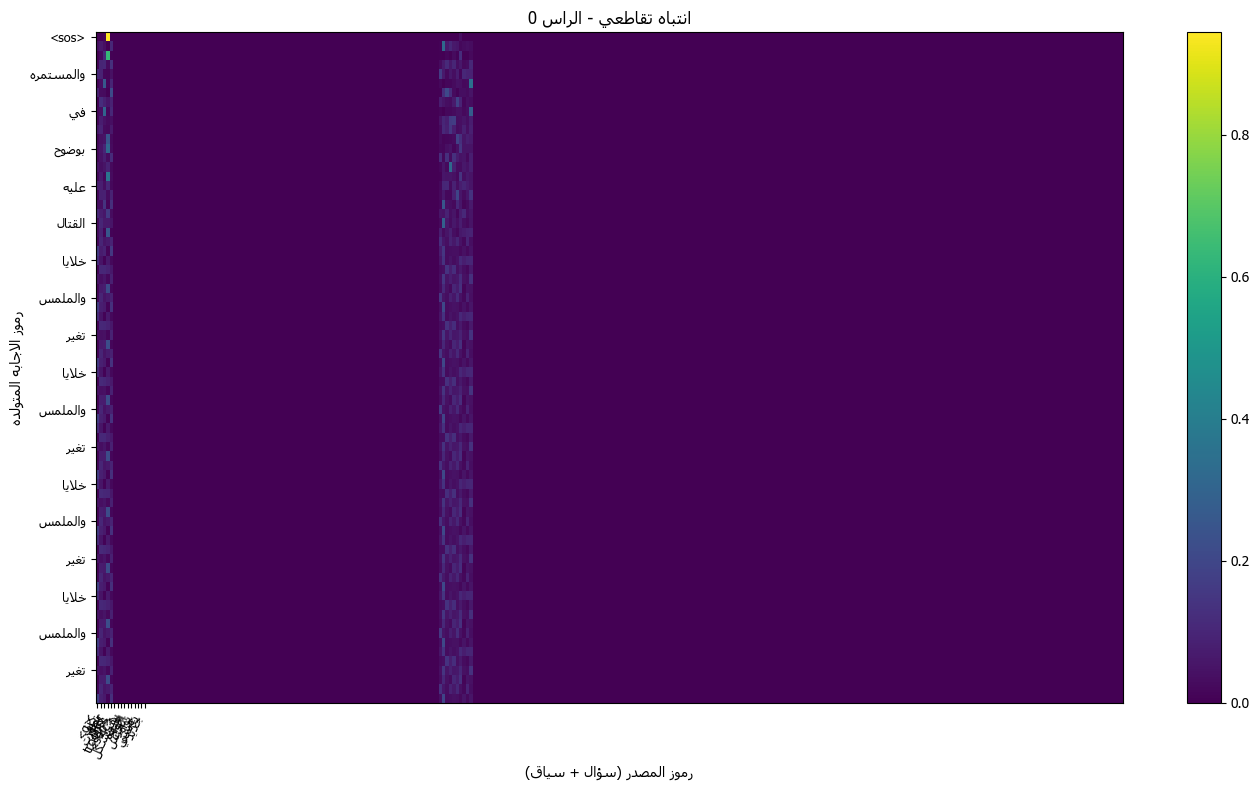

plotted validation sample index: 32


In [620]:
import random
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams
import arabic_reshaper
from bidi.algorithm import get_display

def _pick_arabic_font():
    preferred = ["Tahoma", "Arial", "Segoe UI", "Amiri", "Noto Naskh Arabic"]
    available = {f.name for f in font_manager.fontManager.ttflist}
    for name in preferred:
        if name in available:
            return name
    return "DejaVu Sans"

AR_FONT = _pick_arabic_font()
rcParams["font.family"] = AR_FONT

def shape_arabic(text):
    return get_display(arabic_reshaper.reshape(str(text)))

def _compact_labels(tokens, max_labels=24, max_token_chars=16):
    if not tokens:
        return [], []

    stride = max(1, len(tokens) // max_labels)
    idx = list(range(0, len(tokens), stride))
    labels = []
    for i in idx:
        tok = tokens[i]
        if len(tok) > max_token_chars:
            tok = tok[: max_token_chars - 1] + "…"
        labels.append(shape_arabic(tok))
    return idx, labels

def plot_cross_attention(attn, src_tokens, tgt_tokens, head=0):
    a = attn[0, head].detach().cpu().numpy()

    plt.figure(figsize=(14, 8))
    plt.imshow(a, aspect="auto", cmap="viridis")

    x_idx, x_labels = _compact_labels(src_tokens, max_labels=26, max_token_chars=14)
    y_idx, y_labels = _compact_labels(tgt_tokens, max_labels=18, max_token_chars=14)

    plt.xticks(x_idx, x_labels, rotation=65, ha="right", fontsize=9)
    plt.yticks(y_idx, y_labels, fontsize=9)
    plt.xlabel(shape_arabic("رموز المصدر (سؤال + سياق)"))
    plt.ylabel(shape_arabic("رموز الاجابه المتولده"))
    plt.title(shape_arabic(f"انتباه تقاطعي - الراس {head}"))
    plt.colorbar()
    plt.tight_layout()
    plt.show()

# Pick a random validation sample so the graph can change from run to run.
sample_idx = random.randrange(len(val_ds))
q_ids, c_ids, _ = val_ds[sample_idx]
q_tag = torch.tensor([Q_IDX])
sep = torch.tensor([SEP_IDX])
c_tag = torch.tensor([C_IDX])
src_seq = torch.cat([q_tag, q_ids.long(), sep, c_tag, c_ids.long()], dim=0)[:MAX_SRC_LEN]

# Use generated answer tokens (not teacher-forced gold answer tokens).
pred_ids = greedy_decode(model, src_seq)
tgt_seq = torch.tensor(pred_ids, dtype=torch.long)[:MAX_TGT_LEN]
if tgt_seq.numel() == 0:
    tgt_seq = torch.tensor([SOS_IDX], dtype=torch.long)

src_ex = src_seq.unsqueeze(0).to(device)
tgt_ex = tgt_seq.unsqueeze(0).to(device)
_ = model(src_ex, tgt_ex)
attn = model.decoder.cross_attn.last_attention

src_toks = decode_ids(src_seq.tolist(), drop_special=False).split()
tgt_toks = decode_ids(tgt_seq.tolist(), drop_special=False).split()
plot_cross_attention(attn, src_toks, tgt_toks, head=0)
print(f"plotted validation sample index: {sample_idx}")


In [621]:
print(f"epochs_ran: {epochs_ran}")
print(f"best_val_loss: {best_val:.4f}")

epochs_ran: 40
best_val_loss: 5.6398
